# 1D Heat Equation — Dirichlet BCs, sine initial profile

## Problem

$$\frac{\partial u}{\partial t} = \alpha\,\frac{\partial^2 u}{\partial x^2},
\qquad (t,x) \in (0,T) \times (0,\pi)$$

**Initial condition**

$$u(0,x) = \sin x, \qquad x \in [0,\pi]$$

**Boundary conditions**

$$u(t,0) = 0, \qquad u(t,\pi) = 0, \qquad t \ge 0$$

Parabolic. Physically: a rod of length $\pi$ with both ends held at zero
temperature, starting from a single sine hump. Heat leaks out both ends.

## Exact solution

$\sin x$ is an eigenfunction of $\partial_x^2$ on $[0,\pi]$ with eigenvalue $-1$,
so the profile decays without changing shape:

$$u_{\text{exact}}(t,x) = e^{-\alpha t}\,\sin x$$

We take $\alpha = 1$.

**Compatibility check.** At the corners $(t,x)=(0,0)$ and $(0,\pi)$ the initial
and boundary conditions must agree: $\sin 0 = 0$ and $\sin \pi = 0$, both
matching the boundary value $0$. ✓

## Method

Hard-embed all three conditions in the trial function:

$$u_\theta(t,x) = \underbrace{\sin x}_{\text{satisfies the conditions}}
\;+\; \underbrace{t\,x(\pi - x)}_{\text{vanishes where each condition lives}}
\;\cdot\; \mathrm{NN}(\theta; t, x)$$

- factor $t$ &rarr; kills the second term at $t=0$, leaving $u_\theta(0,x)=\sin x$
- factor $x$ &rarr; kills it at $x=0$, and $\sin 0 = 0$, so $u_\theta(t,0)=0$
- factor $(\pi-x)$ &rarr; kills it at $x=\pi$, and $\sin \pi = 0$, so $u_\theta(t,\pi)=0$

All three hold **exactly**, for any $\theta$. The loss therefore has a single term.

**Residual**

$$R(t,x) = \frac{\partial u_\theta}{\partial t} - \frac{\partial^2 u_\theta}{\partial x^2}$$

**Loss**

$$\mathcal{L}(\theta) = \frac{1}{NM}\sum_{i=1}^{N}\sum_{j=1}^{M} R(t_i, x_j)^2$$

with collocation points $\{t_i\}_{i=1}^{N} \subset (0,T)$ and
$\{x_j\}_{j=1}^{M} \subset (0,\pi)$. No training data — the equation itself
is the supervision.

## Benchmark

Compared against the explicit finite-difference scheme

$$u_i^{n+1} = u_i^n + r\left(u_{i-1}^n - 2u_i^n + u_{i+1}^n\right),
\qquad r = \frac{\Delta t}{\Delta x^2}$$

which is stable only for $r \le \tfrac12$.

In [13]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

In [14]:
def grad(y, x):
    """Derivative of y with respect to x, kept differentiable."""
    return torch.autograd.grad(
        y, x, grad_outputs=torch.ones_like(y), create_graph=True
    )[0]

In [15]:
class HeatPINN(nn.Module):
    def __init__(self, width=64, depth=4):
        super().__init__()
        layers = [nn.Linear(2, width), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(width, width), nn.Tanh()]
        layers += [nn.Linear(width, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, t, x):
        nn_out = self.net(torch.cat([t, x], dim=1))
        # hard embedding: IC at t=0, BCs at x=0 and x=pi
        return torch.sin(x) + t * x * (np.pi - x) * nn_out

In [16]:
# collocation grid: 128 time points x 256 space points
T_max = 1.0
N, M = 128, 256

t_lin = torch.linspace(0, T_max, N)
x_lin = torch.linspace(0, np.pi, M)
T_grid, X_grid = torch.meshgrid(t_lin, x_lin, indexing='ij')

t_col = T_grid.reshape(-1, 1).requires_grad_(True)
x_col = X_grid.reshape(-1, 1).requires_grad_(True)

print(t_col.shape)   # torch.Size([32768, 1])

torch.Size([32768, 1])


In [17]:
model = HeatPINN(width=64, depth=4)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def compute_loss():
    u = model(t_col, x_col)
    u_t = grad(u, t_col)
    u_x = grad(u, x_col)
    u_xx = grad(u_x, x_col)
    residual = u_t - u_xx
    return (residual ** 2).mean()

In [18]:
import time
t0 = time.time()
losses = []

for epoch in range(3000):
    optimizer.zero_grad()
    loss = compute_loss()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if epoch % 500 == 0:
        print(f"epoch {epoch:5d}   loss {loss.item():.3e}")

pinn_time = time.time() - t0
print(f"trained in {pinn_time:.1f}s")

epoch     0   loss 9.590e-02
epoch   500   loss 2.451e-05
epoch  1000   loss 1.505e-05
epoch  1500   loss 3.901e-03
epoch  2000   loss 1.444e-05
epoch  2500   loss 7.423e-06
trained in 724.6s


In [19]:
# evaluate against the exact solution
with torch.no_grad():
    tt = torch.linspace(0, T_max, 100).reshape(-1, 1)
    xx = torch.linspace(0, np.pi, 200).reshape(-1, 1)
    TT, XX = torch.meshgrid(tt.flatten(), xx.flatten(), indexing='ij')
    t_ev = TT.reshape(-1, 1)
    x_ev = XX.reshape(-1, 1)
    u_pred = model(t_ev, x_ev).reshape(100, 200).numpy()

u_exact = np.exp(-TT.numpy()) * np.sin(XX.numpy())
pinn_err = np.abs(u_pred - u_exact).max()
print("PINN max error:", pinn_err)

PINN max error: 0.0004121065


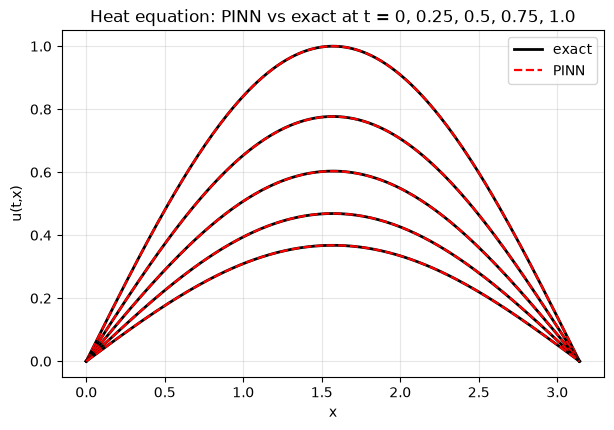

In [20]:
# profile plot at several times
plt.figure(figsize=(7, 4.5))
x_np = xx.numpy().flatten()
for k, ti in enumerate([0, 25, 50, 75, 99]):
    plt.plot(x_np, u_exact[ti], 'k-', lw=2,
             label='exact' if k == 0 else None)
    plt.plot(x_np, u_pred[ti], 'r--', lw=1.6,
             label='PINN' if k == 0 else None)
plt.xlabel('x'); plt.ylabel('u(t,x)')
plt.title('Heat equation: PINN vs exact at t = 0, 0.25, 0.5, 0.75, 1.0')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

In [21]:
def fd_heat(nx, T=1.0, r=0.4):
    """Explicit finite differences for u_t = u_xx on [0,pi]."""
    x = np.linspace(0, np.pi, nx + 1)
    dx = x[1] - x[0]
    dt = r * dx**2                 # r = dt/dx^2 controls stability
    nt = int(np.ceil(T / dt))
    dt = T / nt
    r = dt / dx**2

    u = np.sin(x)                  # initial condition
    for _ in range(nt):
        un = u.copy()
        u[1:-1] = un[1:-1] + r * (un[:-2] - 2*un[1:-1] + un[2:])
        u[0] = 0.0                 # boundary conditions
        u[-1] = 0.0
    exact = np.exp(-T) * np.sin(x)
    return x, u, nt, np.abs(u - exact).max()

for nx in [10, 20, 40, 80]:
    x, u, nt, err = fd_heat(nx)
    print(f"nx={nx:3d}  steps={nt:5d}  max error={err:.3e}")

nx= 10  steps=   26  max error=4.102e-03
nx= 20  steps=  102  max error=1.050e-03
nx= 40  steps=  406  max error=2.642e-04
nx= 80  steps= 1622  max error=6.614e-05


In [22]:
for r in [0.4, 0.5, 0.6]:
    x, u, nt, err = fd_heat(20, T=2.0, r=r)
    print(f"r={r}:  max|u| at t=2 = {np.abs(u).max():.4e}   "
          f"(exact {np.exp(-2):.4f})")

r=0.4:  max|u| at t=2 = 1.3456e-01   (exact 0.1353)
r=0.5:  max|u| at t=2 = 1.3423e-01   (exact 0.1353)
r=0.6:  max|u| at t=2 = 2.9837e+01   (exact 0.1353)
